# Setup

In [12]:
import requests
from bs4 import BeautifulSoup
from typing import List, Optional, TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field, ConfigDict
from langchain.chat_models import init_chat_model


load_dotenv()
llm = init_chat_model('gpt-4.1-mini')

# Schemas

In [13]:
from typing import List, Optional, Union, Literal
from pydantic import BaseModel, Field, ConfigDict

# OpenAI Strict 모드를 위한 공통 설정
STRICT_CONF = ConfigDict(extra='forbid')

# 비판 결과 스키마
class CriticReview(BaseModel):
    model_config = STRICT_CONF
    is_perfect: bool = Field(description="논리적 오류가 전혀 없으면 True")
    critique_points: List[str] = Field(default=[], description="오류 지점 및 수정 요구사항 목록")
    severity: Literal["CRITICAL", "MINOR", "NONE"] = Field(description="오류의 심각도")
    
class OptionSummary(BaseModel):
    model_config = STRICT_CONF
    option_name: str
    brief_description: str # 예: "스타벅스 50% 할인 + 편의점 7% 할인"

class OptionsPreview(BaseModel):
    model_config = STRICT_CONF
    summaries: List[OptionSummary]

# 판단 노드(Decision Node) 전용 스키마
class FlowDecision(BaseModel):
    model_config = STRICT_CONF
    # Literal 타입으로 'direct'와 'selection'만 허용
    decision: Literal["direct", "selection"] = Field(
        description="단일 카드면 'direct', 선택이 필요하면 'selection'"
    )
    options: List[str] = Field(default=[], description="선택형일 경우 후보군 카드 이름 리스트")
    reason: str = Field(description="그렇게 판단한 이유")

# 1. 최하위 계층
class PerformanceTier(BaseModel):
    model_config = STRICT_CONF
    tier_min: int
    limit: int

class BenefitLimit(BaseModel):
    model_config = STRICT_CONF
    monthly: Optional[int] = None
    yearly: Optional[int] = None
    monthly_performance_tiers: Optional[List[PerformanceTier]] = None

class BenefitCondition(BaseModel):
    model_config = STRICT_CONF
    min_performance: int = 0
    min_per_transaction: Optional[int] = Field(None, description="혜택을 받기 위한 건당 최소 결제 금액")
    payment_method: str = "ANY"
    is_overseas_only: Optional[bool] = None
    location_exclude: Optional[List[str]] = None
    per_transaction_cap: Optional[int] = None
    platform: Optional[str] = None
    domestic_only: Optional[bool] = None

class PerformanceImpact(BaseModel):
    model_config = STRICT_CONF
    counts_toward_performance: bool
    is_all_or_nothing_exclusion: bool = False
    comment: Optional[str] = None

CardCategory = Literal[
    "FOOD",                   # 1. 음식점
    "DELIVERY",               # 2. 배달
    "CAFE_BAKERY",            # 3. 카페/베이커리
    "MEDICAL",                # 4. 병원/약국
    "EDUCATION",              # 5. 학원/교육
    "PARKING_LOT",            # 6. 주차장
    "OIL",                    # 7. 주유소
    "TRANSPORTATION",         # 8. 대중교통
    "TELECOM_UTILITY",        # 9. 통신/공과금
    "CONVENIENCE",            # 10. 편의점
    "SHOPPING",               # 11. 쇼핑 (마트, 백화점 등)
    "CULTURE_ENTERTAINMENT",  # 12. 문화/엔터 (영화, 테마파크 등)
    "SUBSCRIPTION",           # 13. 구독서비스
    "OVERSEAS",               # 14. 해외 결제
    "TRAVEL",                 # 15. 여행 (항공, 숙박 등)
    "AIRPORT_LOUNGE",         # 16. 공항 라운지
    "OTHER"                   # 17. 기타
]

BenefitType = Literal[
    "PERCENT_DISCOUNT",    # % 할인
    "KRW_DISCOUNT",        # 원 단위 할인
    "CASHBACK",            # 현금 캐시백
    "POINT_ACCUMULATION",  # 포인트 적립
    "FEE_WAIVER",          # 수수료 면제
    "FREE_ACCESS"          # 무료 이용 (라운지 등)
]
BenefitUnit = Literal["PERCENT", "KRW", "COUNT"]

class CardBenefit(BaseModel):
    model_config = ConfigDict(extra='forbid') 
    
    benefit_id: str = Field(description="혜택의 고유 ID (예: COFFEE_50)")
    category: CardCategory = Field(description="DB 매핑용 카테고리")
    merchant: Optional[List[str]] = Field(default=None, description="혜택 가맹점 리스트")
    type: BenefitType = Field(description="혜택의 종류 (객관식)")
    value: float = Field(description="혜택의 수치 (10.0, 5000.0 등)")
    unit: BenefitUnit = Field(description="수치의 단위 (PERCENT, KRW, COUNT)")
    
    conditions: 'BenefitCondition'
    limits: 'BenefitLimit'
    performance_impact: 'PerformanceImpact'

# 2. 중간 계층 (Logic 파트)
class PerformanceLogic(BaseModel):
    model_config = STRICT_CONF
    calculation_period: str
    global_performance_exclusion: List[str]
    domestic_only_performance: bool

class GracePeriodLogic(BaseModel):
    model_config = STRICT_CONF
    duration: str
    default_benefit_tier: str
    daily_life_limit: int
    air_dutyfree_limit: int
    transport_limit: int

# 3. 최상위 계층 (Root)
class CardDataSchema(BaseModel):
    model_config = STRICT_CONF
    card_id: str
    card_name: str
    issuer: str
    card_type: Literal["CREDIT", "CHECK"] = Field(description="카드의 종류 (CREDIT 또는 CHECK)")
    critical_warning: str
    performance_logic: PerformanceLogic
    benefits: List[CardBenefit]
    grace_period_logic: GracePeriodLogic

class CombinedDecision(BaseModel):
    decision: Literal["direct", "selection"]
    options: List[str] = Field(default=[], description="선택형일 경우 후보군 이름")
    summaries: List[OptionSummary] = Field(default=[], description="선택지별 요약 정보")
    reason: str

In [14]:
from typing import List, Optional, Union, Literal

class State(TypedDict):
    card_id: str
    card_name: Optional[str]
    raw_text: Optional[str]
    formatted_md: Optional[str]  
    decision: Optional[Literal["direct", "selection"]]    
    options_list: List[str]        # AI가 찾아낸 후보군 이름들
    summaries: List[OptionSummary] # 사용자에게 보여줄 패키지별 요약 텍스트
    selected_option: Optional[str] # 사용자가 최종 선택한 패키지명
    critic_feedback: Optional[dict]
    output_json: Optional[dict]
    iteration_count: int = 0
    is_manually_fixed: Optional[bool]

# Nodes

In [15]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
import json
from server.database.connection import get_db_conn
import os
import requests
from bs4 import BeautifulSoup
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()

# OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


# 시작: 카드 정보 받아오기
def node_ingest_card_data(state: State):
    card_id = state["card_id"]
    print(f" [Node: Ingest] 카드 ID {card_id} 크롤링 시작...")

    url = f"https://api.card-gorilla.com:8080/v1/cards/{card_id}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36...",
    }

    # 실제 요청 수행
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise Exception(f"데이터 로드 실패: {response.status_code}")

    data = response.json()

    # 텍스트 정제 (BeautifulSoup 활용)
    benefit_segments = []
    for benefit in data.get("key_benefit", []):
        soup = BeautifulSoup(benefit.get("info", ""), "html.parser")
        benefit_segments.append(
            f"[{benefit.get('title')}]\n{soup.get_text(separator=' ').strip()}"
        )

    return {"card_name": data.get("name"), "raw_text": "\n\n".join(benefit_segments)}


# Node 0: 받아온 정보를 마크다운 형식으로 정제
def node_format_markdown(state: State):
    print("[Node 0: Format] 원문을 마크다운 구조로 정제 중...")
    
    system_msg = """너는 금융 상품 설명서 전문 편집자야. 
    네 임무는 입력된 '비정형 카드 혜택 텍스트'를 데이터 누락 없이 '구조화된 마크다운(Markdown)' 문서로 재구성하는 것이야.

    [준수 규칙]
    1. 전량 보존(Lossless): 원문에 포함된 모든 수치, 조건, 유의사항, 예외 조항을 단 하나도 생략하거나 요약하지 마.
    2. 표 구조화(Table First): 수치나 조건이 나열된 구간은 마크다운 테이블(|---|) 형식을 사용해.
    3. 혜택별 헤딩 분리 (가장 중요): 모든 혜택을 하나의 거대한 표로 뭉뚱그리지 마! 반드시 혜택의 카테고리(예: 편의점, 카페, 통신요금 등)마다 '## [카테고리명]'으로 독립된 헤딩을 작성하고, 그 아래에 해당 혜택의 표나 유의사항을 적어.
    4. 항목 구분: 전월 실적 제외 대상 등 줄글 정보는 불렛 포인트(*)를 사용해.
    5. 원문 강조: '실적 제외', '한도 차등 적용' 등 독소 조항 키워드는 **볼드** 처리해."""
    
    response = llm.invoke([
        {"role": "system", "content": system_msg},
        {"role": "user", "content": f"원문 텍스트:\n{state['raw_text']}"}
    ])
    
    return {"formatted_md": response.content}

# Node A: 마크다운으로 정제된 텍스트를 벡터화하여 DB에 저장
def get_embedding(text):
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding
def node_vector_db_commit(state: State):
    card_id = state["card_id"]
    card_name = state.get("card_name", "알 수 없는 카드")
    formatted_md = state.get("formatted_md", "")
    
    print(f"[Node: Vector DB] '{card_name}' 벡터화 및 저장 시작...")

    # 카드사 추출 
    completion = client.chat.completions.create(
        model="gpt-4.1-mini", 
        messages=[
            {
                "role": "system", 
                "content": "당신은 팩트 기반 정보 추출 전문가입니다. 제공된 신용카드 약관 텍스트를 꼼꼼히 읽고, 해당 카드를 발급한 '카드회사 이름(예: KB국민카드, 신한카드, 현대카드 등)'만 찾아내어 단답형으로 출력하세요. 이름만 보고 임의로 유추하는 것을 엄격히 금지합니다. 텍스트 내에서 증거를 찾을 수 없다면 반드시 '알 수 없는 회사'라고 출력하세요."
            },
            {
                "role": "user", 
                "content": f"카드 원문 텍스트: {formatted_md[:3000]}"
            }
        ],
        temperature=0 
    )
    card_company = completion.choices[0].message.content.strip()

    # 16개 카테고리 키워드 정의
    keywords_map = {
        "FOOD": ["음식점", "식당", "외식", "패밀리레스토랑"],
        "DELIVERY": ["배달", "배달의민족", "요기요", "쿠팡이츠"],
        "CAFE_BAKERY": ["카페", "스타벅스", "베이커리", "커피", "디저트", "투썸", "이디야", "파리바게뜨", "뚜레쥬르"],
        "MEDICAL": ["병원", "약국", "치과", "한의원", "의료", "건강검진"],
        "EDUCATION": ["학원", "교육", "학습지", "서점", "도서", "강의", "유치원"],
        "PARKING_LOT": ["주차장", "주차", "발레파킹"],
        "OIL": ["주유", "GSCALTEX", "S-OIL", "현대오일뱅크", "SK에너지", "충전소"],
        "TRANSPORTATION": ["대중교통", "버스", "지하철", "택시", "철도", "KTX", "SRT", "K-패스"],
        "TELECOM_UTILITY": ["통신", "SKT", "KT", "LGU+", "이동통신", "공과금", "관리비", "가스비", "전기요금"],
        "CONVENIENCE": ["편의점", "CU", "GS25", "세븐일레븐", "이마트24", "다이소", "올리브영"],
        "SHOPPING": ["마트", "이마트", "홈플러스", "롯데마트", "백화점", "아울렛", "쇼핑", "쿠팡", "온라인쇼핑", "오픈마켓", "11번가"],
        "CULTURE_ENTERTAINMENT": ["영화", "CGV", "메가박스", "롯데시네마", "문화", "공연", "전시", "테마파크", "놀이공원"],
        "SUBSCRIPTION": ["구독", "넷플릭스", "유튜브", "프리미엄", "디즈니플러스", "멜론", "스트리밍"],
        "OVERSEAS": ["해외", "직구", "가맹점(해외)", "아마존", "알리", "테무"],
        "TRAVEL": ["항공", "항공권", "면세점", "호텔", "숙박", "여행사", "렌터카", "야놀자", "여기어때"],
        "AIRPORT_LOUNGE": ["라운지", "공항서비스", "마티나", "스카이허브", "인천공항", "공항발레파킹", "더라운지", "라운지키"]
    }

    try:
        with get_db_conn() as conn:
            with conn.cursor() as cur:
                
                # 마크다운 문서를 혜택 단위(##)로 쪼개서 저장 (검색 품질 상승을 위함)
                # "## (선택형 팩 이름)" 등으로 계층화했기 때문에 이 기준으로 쪼개면 훌륭한 Chunking이 됩니다.
                chunks = formatted_md.split("## ")
                
                for chunk in chunks:
                    if len(chunk.strip()) < 10:  # 너무 짧은 텍스트(공백 등)는 무시
                        continue
                        
                    # 카테고리 분류 로직 (Chunk 텍스트 기반)
                    found_categories = [
                        cat for cat, kws in keywords_map.items() 
                        if any(kw in chunk for kw in kws)
                    ]
                    final_category = found_categories[0] if found_categories else "OTHER"

                    # 텍스트 병합 및 임베딩
                    full_text = f"카드명: {card_name} | 내용: {chunk.strip()}"
                    embedding = get_embedding(full_text)

                    # DB Insert
                    cur.execute("""
                        INSERT INTO card_benefit_vectors 
                        (card_id, card_company, card_name, benefit_category, content, embedding)
                        VALUES (%s, %s, %s, %s, %s, %s)
                    """, (
                        card_id, card_company, card_name, 
                        final_category, full_text, embedding
                    ))
                
                conn.commit()
                print(f"[Node: Vector DB] '{card_name}' Vector DB 저장 완료!")

    except Exception as e:
        print(f"Vector DB 오류 발생: {e}")
        
    return {} # State 자체를 수정할 필요는 없으므로 빈 딕셔너리 반환





def node_decide_and_summarize(state: State):
    print("[Node: Decide & Summarize] 카드 타입 판단 및 요약 생성 중...")
    
    # raw_text 대신 formatted_md를 사용하여 정확도 향상
    input_text = state.get("formatted_md") or state.get("raw_text")

    structured_llm = llm.with_structured_output(CombinedDecision)
    prompt = ChatPromptTemplate.from_template(
        """
        입력된 카드 혜택 마크다운 문서를 분석하여 '선택형 패키지' 유무를 판단하라.
        
        [판단 기준]
        - 선택 혜택: 사용자가 'A팩', 'B팩' 또는 '1형', '2형' 중 하나를 선택해야만 혜택을 받는 경우.
        - 단일 카드: 모든 혜택이 공통적으로 적용되거나, 단순히 카테고리가 나열된 경우.

        [텍스트]: {text}
        """
    )

    response = structured_llm.invoke(prompt.format(text=input_text))

    # 후처리: options_list가 비어있는데 decision이 selection인 경우 방지
    decision = response.decision
    if decision == "selection" and not response.options:
        decision = "direct"

    return {
        "decision": decision,
        "options_list": response.options,
        "summaries": response.summaries
    }

# 라우터
# '선택'이 필요하면 요약 노드로, 아니면 추출 노드로
def router(state: State):
    if state.get("decision") == "selection":
        return "SummarizeOptions"  
    return "ExtractData"




# 선택형 카드의 경우, 사용자에게 선택지를 보여주고 입력을 기다리는 노드
def node_wait_user_choice(state: State):
    # 1. 요약된 내용 출력 (summaries가 문자열이라면 그대로 출력)
    print("\n[AI 요약 리포트]")
    for i, s in enumerate(state["summaries"], 1):
        print(f"{i}. {s.option_name}: {s.brief_description}")
    # 2. 인터럽트 발생 (사용자 입력 대기)
    # CLI 환경: 여기서 멈추고 입력을 기다림
    user_input = interrupt(
        {
            "question": "분석할 패키지 번호(1~6)나 이름을 입력해주세요.",
            "options": state["options_list"],
        }
    )

    # 3. 입력값 처리 (번호인지 이름인지 판단)
    selected = None

    # 입력이 숫자(1, 2, 3...)인 경우 처리
    if str(user_input).isdigit():
        idx = int(user_input) - 1
        if 0 <= idx < len(state["options_list"]):
            selected = state["options_list"][idx]
            print(f"{idx+1}번({selected})이 선택되었습니다.")

    # 입력이 이름인 경우 처리
    if not selected:
        selected = user_input
        print(f"'{selected}' 패키지가 선택되었습니다.")

    # 4. 다음 단계를 위해 State 업데이트
    # decision을 'direct'로 바꿔야 추출 노드로 넘어감.
    return {
        "decision": "direct",
        "selected_option": selected,
        "card_name": f"{state['card_name']} ({selected})",
    }




# Node : JSON 추출 노드
def node_extract_data(state: State):
    print(f"[Node: Extract] '{state['card_name']}' 데이터 정밀 분석 및 JSON 생성 중...")

    structured_llm = llm.with_structured_output(CardDataSchema)

    selected_info = (
        f"사용자가 선택한 옵션: {state.get('selected_option', '기본/단일 패키지')}"
    )

    feedback_section = ""
    if state.get("critic_feedback") and not state["critic_feedback"].get("is_perfect"):
        points = "\n- ".join(state["critic_feedback"].get("critique_points", []))
        feedback_section = f"\n\n [비판자 피드백 반영 필요]:\n- {points}"

    system_msg = f"""너는 신용카드 약관 분석 전문가야. 아래 규칙을 엄격히 준수해.

    [데이터 규격 규칙]
    - category: FOOD, DELIVERY, CAFE_BAKERY, MEDICAL, EDUCATION, PARKING_LOT, OIL, TRANSPORTATION, TELECOM_UTILITY, CONVENIENCE, SHOPPING, CULTURE_ENTERTAINMENT, SUBSCRIPTION, OVERSEAS, TRAVEL, AIRPORT_LOUNGE, OTHER 중 하나만 선택.
    - type: PERCENT_DISCOUNT, KRW_DISCOUNT, CASHBACK, POINT_ACCUMULATION, FEE_WAIVER, FREE_ACCESS 중 하나만 선택.
    - unit: PERCENT, KRW, COUNT 중 하나만 선택.
    - card_type 추출: 카드의 연회비 유무나 결제 방식을 보고 CREDIT(신용) 또는 CHECK(체크) 중 하나를 정확히 판별해.

    [추출 지시]
    1. {selected_info}에 해당하는 혜택 정보를 집중적으로 분석해.
    2. '전월 실적 제외 항목'을 global_performance_exclusion에 빠짐없이 나열해.
    3. 특히 '할인 받은 결제 건이 실적에서 제외되는지' 여부를 performance_impact의 is_all_or_nothing_exclusion에 정확히 기록해.
    4. 실적 구간별로 한도가 다르다면 monthly_performance_tiers에 모든 구간을 명시해.{feedback_section}
    5. '건당 최소 결제 금액' 조건이 있는지 텍스트에서 눈을 부릅뜨고 찾아내어 min_per_transaction에 기록해.
    6. '혜택 제외 가맹점'(백화점, 대형마트, 역사 내 매장 등)은 반드시 conditions.location_exclude에 리스트로 넣어.
    7. '무이자 할부 시 혜택 제외' 여부를 확인하여 critical_warning에 반드시 포함시켜.
    """


    result = structured_llm.invoke(
        [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": f"카드 원문 텍스트:\n{state['formatted_md']}"},
        ]
    )

    result_dict = result.model_dump()
    result_dict["card_id"] = state["card_id"]

    return {
        "output_json": result_dict,
        "iteration_count": state.get("iteration_count", 0) + 1,
    }








# Node: 비판자 노드 - 추출된 JSON과 정제된 텍스트를 비교하여 논리적 오류 검토
def node_critic(state: State):
    print(f"[Node: Critic] 추출된 데이터의 논리 결함을 검토 중... (시도 {state.get('iteration_count', 0)}회)")

    critic_llm = llm.with_structured_output(CriticReview)

    prompt = ChatPromptTemplate.from_template(
        """
    너는 카드 약관 분석 전문가이자 깐깐한 감사관이야. 
    [정제된 텍스트]와 [추출된 JSON]을 비교해서 논리적 오류를 찾아내.
    특히 '전월 실적 제외 항목'과 '혜택 적용 제외 항목'이 정확히 반영되었는지 독사처럼 감시해.
    performance_impact의 comment 내용과 counts_toward_performance 불리언 값이 서로 모순되지 않는지 반드시 체크해. 
    텍스트로는 포함된다고 하고 값은 제외라고 하면 그건 실패(is_perfect: False)야.
    [정제된 텍스트]: {formatted_md}
    [추출된 JSON]: {output_json}
    """
    )

    review = critic_llm.invoke(
        prompt.format(
            formatted_md=state["formatted_md"],
            output_json=json.dumps(state["output_json"], ensure_ascii=False),
        )
    )

    return {"critic_feedback": review.model_dump()}










from langgraph.types import interrupt



def node_admin_review(state: State):
    print(
        "\n[Node: Admin Review] AI가 데이터 추출에 실패했습니다. 관리자 개입이 필요합니다."
    )
    print(f"비판자 지적 사항: {state['critic_feedback'].get('critique_points')}")

    # 관리자에게 수정된 JSON 입력을 요청 (interrupt 사용)
    # 실제 환경에서는 UI를 통해 JSON 편집기를 띄워주는 역할을 함.
    fixed_json = interrupt(
        {
            "message": "AI가 추출에 실패한 항목을 직접 수정하여 입력해주세요.",
            "current_json": state["output_json"],
            "error_reasons": state["critic_feedback"].get("critique_points"),
        }
    )

    # 관리자가 수정한 데이터로 업데이트하고 종료 단계로 보냄.
    return {
        "output_json": fixed_json,
        "is_manually_fixed": True,  # 사람이 직접 수정했다는 플래그
    }

import os
from psycopg2.extras import Json
from typing import Any, Dict


def node_db_commit(state: Dict[str, Any]):
    # 1. 추출된 데이터(output_json) 가져오기
    out = state.get("output_json", {})
    if not out:
        print("[Node: DB Commit] 저장할 데이터가 없습니다. 스킵합니다.")
        return {"is_committed": False}

    card_id = state.get("card_id")
    
    # 2. 동적 데이터 추출 (LLM이 추출한 값 우선, 없으면 State 값 사용)
    card_company = out.get("issuer") or state.get("card_company", "알 수 없는 회사")
    card_name = out.get("card_name") or state.get("card_name")
    
    # card_type을 추출 결과에서 가져오도록 변경 (Credit/Check 구분)
    # CardDataSchema에 card_type 필드를 추가하여 LLM이 추출하게 하는 것이 가장 좋습니다.
    card_type = out.get("card_type") or state.get("card_type", "CHECK")

    print(f"[Node: DB Commit] 카드 '{card_name}'({card_id}) DB 저장 시도...")

    try:
        with get_db_conn() as conn:
            with conn.cursor() as cur:
                # 3. UPSERT 쿼리 (성능과 정합성을 위해 명시적 필드 업데이트)
                query = """
                    INSERT INTO card_master (
                        card_id, 
                        card_company, 
                        card_name, 
                        card_type, 
                        benefits_json,
                        updated_at
                    ) VALUES (%s, %s, %s, %s, %s, CURRENT_TIMESTAMP)
                    ON CONFLICT (card_id) 
                    DO UPDATE SET 
                        card_company = EXCLUDED.card_company,
                        card_name = EXCLUDED.card_name,
                        card_type = EXCLUDED.card_type,
                        benefits_json = EXCLUDED.benefits_json,
                        updated_at = CURRENT_TIMESTAMP;
                """

                cur.execute(
                    query,
                    (
                        card_id,
                        card_company,
                        card_name,
                        card_type,
                        Json(out), # out 전체를 JSONB로 저장
                    ),
                )
                conn.commit()
                print(f"✅ DB 저장 성공: {card_company} - {card_name}")

    except Exception as e:
        print(f"DB 저장 실패: {str(e)}")
        # 필요 시 에러 발생시켜 워크플로우 중단
        raise e

    return {"is_committed": True}

# Router

In [ ]:

def critic_router(state: State):
    feedback = state.get("critic_feedback")
    iteration = state.get("iteration_count", 0)

    # 1. 완벽하면 DB 저장으로 통과
    if feedback and feedback.get("is_perfect"):
        return "DBCommit"

    # 2. 완벽하지 않아도 심각도가 MINOR이고 2번 이상 시도했다면 일단 저장 (관용)
    if feedback and feedback.get("severity") == "MINOR" and iteration >= 2:
        print("[Router] 사소한 오류가 있으나 2회 이상 시도하여 통과시킵니다.")
        return "DBCommit"

    # 3. 3회 이상 실패하면 관리자 개입 노드로
    if iteration >= 3:
        return "AdminReview"

    # 그 외에는 수정해야 하므로 다시 추출 노드로
    return "ExtractData"

# Graph

In [18]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

# 1. 그래프 초기화
graph = StateGraph(State)

# 2. 노드 등록
graph.add_node("IngestData", node_ingest_card_data)
graph.add_node("FormatMarkdown", node_format_markdown)   
graph.add_node("VectorDB", node_vector_db_commit) 
# 🔥 기존 DecideFlow와 SummarizeOptions를 통합한 노드
graph.add_node("DecideAndSummarize", node_decide_and_summarize) 
graph.add_node("WaitUserChoice", node_wait_user_choice)
graph.add_node("ExtractData", node_extract_data)
graph.add_node("Critic", node_critic)             
graph.add_node("AdminReview", node_admin_review) 
graph.add_node("DBCommit", node_db_commit) 

# 3. 엣지 연결 (순차 및 병렬 구조)
graph.add_edge(START, "IngestData")
graph.add_edge("IngestData", "FormatMarkdown") 

# 병렬 분기: 마크다운 정제 후 Vector DB 저장과 판단 로직 동시 진행
graph.add_edge("FormatMarkdown", "VectorDB") 
graph.add_edge("FormatMarkdown", "DecideAndSummarize") 

# 4. 조건부 분기 (Router 매핑 수정)
# 통합된 노드 이후의 라우팅 결정
graph.add_conditional_edges(
    "DecideAndSummarize",
    router, 
    {
        "SummarizeOptions": "WaitUserChoice", # 선택형일 경우 사용자 입력 대기로 이동
        "ExtractData": "ExtractData"          # 단일형일 경우 바로 추출로 이동
    }
)

# 선택형 흐름: 사용자 선택 완료 후 추출로 이동
graph.add_edge("WaitUserChoice", "ExtractData") 

# 추출 후 비판(Critic) 루프 진입
graph.add_edge("ExtractData", "Critic")

# 5. 비판 결과에 따른 조건부 분기 (Router 반환값 일치화)
graph.add_conditional_edges(
    "Critic",
    critic_router,
    {
        "ExtractData": "ExtractData", # FAIL: 다시 재수정(추출)
        "DBCommit": "DBCommit",       # PASS: 최종 저장
        "AdminReview": "AdminReview"  # Critical Error/Max Retries: 관리자 개입
    }
)

# 최종 경로 및 종료
graph.add_edge("AdminReview", "DBCommit")
graph.add_edge("DBCommit", END)
graph.add_edge("VectorDB", END) # Vector DB 저장이 끝나면 해당 가지 종료

# 6. 컴파일
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

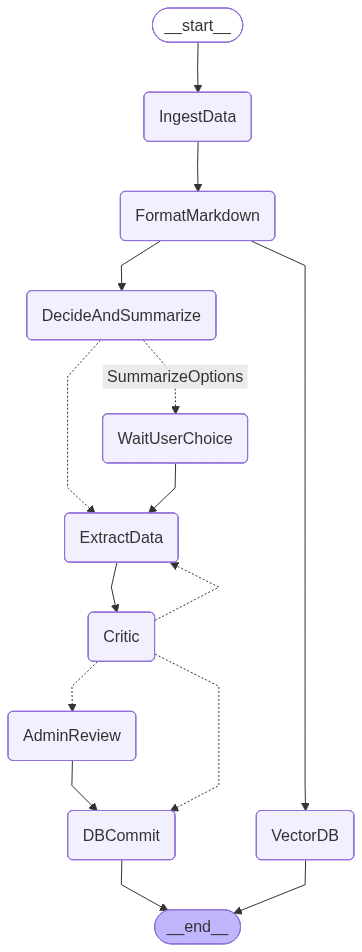

In [19]:
from IPython.display import Image, display

# 컴파일된 app의 그래프를 PNG 이미지로 렌더링하여 출력
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 렌더링 실패: {e}")

# Run

In [8]:
# 1. 실행 설정 정의
config = {"configurable": {"thread_id": "card_analysis_session_03"}}

if __name__ == "__main__":
    initial_input = {"card_id": "2749", "options_list": []}
    
    # 2. invoke 호출 시 config를 함께 넘김
    # '선택' 노드에서 멈춤
    final_state = app.invoke(initial_input, config=config)
    
    # interrupt가 발생하면 여기서 실행이 멈춤.
    if final_state.get("output_json"):
        print("분석 완료!")

 [Node: Ingest] 카드 ID 2749 크롤링 시작...
[Node 0: Format] 원문을 마크다운 구조로 정제 중...
[Node: Decide] 단일 카드인지 선택형인지 판단 중...


KeyError: 'SummarizeOptions'

In [ ]:
import json

# 분석이 끝났는지 확인하고 출력
if "output_json" in final_state and final_state["output_json"]:
    print(f"[{final_state['card_name']}] 분석 완료!")
    print(json.dumps(final_state["output_json"], indent=2, ensure_ascii=False))
else:
    print("아직 결과가 생성되지 않았습니다. 로그를 확인해 주세요.")

In [77]:
from langgraph.types import Command

# 사용자가 입력하고 싶은 번호 (예: "1")
user_input = "1" 

# 멈춘 지점부터 다시 시작 (동일한 config 사용)
final_result = app.invoke(Command(resume=user_input), config=config)

# 최종 결과물 출력
if final_result.get("output_json"):
    print("\n최종 분석이 완료되었습니다!")
    import json
    print(json.dumps(final_result["output_json"], indent=2, ensure_ascii=False))

Deserializing unregistered type __main__.OptionSummary from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'OptionSummary')]
Deserializing unregistered type __main__.OptionSummary from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'OptionSummary')]



[AI 요약 리포트]
1. A팩: OTT(넷플릭스, 유튜브 등) 50% 할인 월 5,000원 한도, 앱스토어 30% 할인 월 5,000원 한도, 노래방/PC방 20% 할인 월 2,000원 한도, 택시/철도 20% 할인 월 2,000원 한도, 편의점 20% 할인 월 2,000원 한도, 영화관 4,000원 1회 할인 (월 15,000원 이상 결제 시 적용)
2. B팩: 쇼핑 멤버십(네이버 플러스, 쿠팡 와우) 50% 할인 월 5,000원 한도, 통신요금 30% 할인 월 5,000원 한도, 패션/라이프 온라인몰 및 올리브영 등 20% 할인 월 2,000원 한도, 배달앱 20% 할인 월 2,000원 한도, 편의점 20% 할인 월 2,000원 한도, 데이트 레스토랑 및 놀이공원 4,000원 1회 할인 (월 10,000원 이상 결제 시 적용)
1번(A팩)이 선택되었습니다.
[Node: Extract] 'KB Youth Club 체크카드 (A팩)' 데이터 정밀 분석 및 JSON 생성 중...
[SSH Tunneling] RDS 접속을 위해 터널을 개방합니다...
DB 저장 성공 (ID: 2929)

최종 분석이 완료되었습니다!
{
  "card_id": "2929",
  "card_name": "KB Youth Club 체크카드 A팩",
  "issuer": "KB국민카드",
  "critical_warning": "무이자 할부 시 혜택 제외 여부 명시 없음 (필히 확인 필요)",
  "performance_logic": {
    "calculation_period": "전월 1일~말일(승인시점 기준)",
    "global_performance_exclusion": [
      "포인트리 충전금액",
      "상품권 및 선불카드 구입·충전 금액",
      "아파트관리비",
      "정부지원금(보육료, 유치원보조비, 바우처 이용금액 등)",
      "대학(원)등록금",
      "국세",
      "지방세",
      "4대 사회보험료(건강/연금

# Vector DB 저장용

In [78]:
import os
import requests
import psycopg2
from bs4 import BeautifulSoup
from openai import OpenAI
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv
from server.database.connection import get_db_conn


load_dotenv()

# 1. OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def get_embedding(text):
    # 최신 가성비 모델인 text-embedding-3-small 사용
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding

def store_card_to_vector_db(card_id):
    # --- API 요청 파트 ---
    url = f"https://api.card-gorilla.com:8080/v1/cards/{card_id}"
    headers = {"User-Agent": "Mozilla/5.0", "Accept": "application/json"}
    
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print("API 호출 실패")
        return

    data = response.json()
    card_name = data.get("card_name") or data.get("name") or "알 수 없는 카드"

    # 1. 원문 텍스트를 모두 하나로 병합 (카드사 단서 확보용)
    all_text_for_search = ""
    for benefit in data.get("key_benefit", []):
        raw_info = benefit.get("info", "")
        soup = BeautifulSoup(raw_info, "html.parser")
        all_text_for_search += soup.get_text(separator=" ").strip() + " "

    # 2. LLM에게 추측이 아닌 '텍스트 내 팩트 추출'을 강제 지시
    print(f"원문 텍스트에서 [{card_name}]의 정확한 카드사 정보 추출 중...")
    completion = client.chat.completions.create(
        model="gpt-4.1-mini", 
        messages=[
            {
                "role": "system", 
                "content": "당신은 팩트 기반 정보 추출 전문가입니다. 제공된 신용카드 약관 텍스트를 꼼꼼히 읽고, 해당 카드를 발급한 '카드회사 이름(예: KB국민카드, 신한카드, 현대카드 등)'만 찾아내어 단답형으로 출력하세요. 이름만 보고 임의로 유추하는 것을 엄격히 금지합니다. 텍스트 내에서 증거를 찾을 수 없다면 반드시 '알 수 없는 회사'라고 출력하세요."
            },
            {
                "role": "user", 
                "content": f"카드 원문 텍스트: {all_text_for_search[:3000]}" # 핵심 약관은 대부분 앞부분에 있으므로 3000자 제한으로 비용 절감
            }
        ],
        temperature=0 
    )
    card_company = completion.choices[0].message.content.strip()
    
    # 환경 변수 로드
    ssh_host = os.getenv("SSH_HOST")
    rds_host = os.getenv("RDS_HOST")

    print(f"[{card_name}] 벡터화 및 저장 시작...")

# 16개 카테고리 키워드 정의
    keywords_map = {
        "FOOD": ["음식점", "식당", "외식", "패밀리레스토랑"],
        "DELIVERY": ["배달", "배달의민족", "요기요", "쿠팡이츠"],
        "CAFE_BAKERY": ["카페", "스타벅스", "베이커리", "커피", "디저트", "투썸", "이디야", "파리바게뜨", "뚜레쥬르"],
        "MEDICAL": ["병원", "약국", "치과", "한의원", "의료", "건강검진"],
        "EDUCATION": ["학원", "교육", "학습지", "서점", "도서", "강의", "유치원"],
        "PARKING_LOT": ["주차장", "주차", "발레파킹"],
        "OIL": ["주유", "GSCALTEX", "S-OIL", "현대오일뱅크", "SK에너지", "충전소"],
        "TRANSPORTATION": ["대중교통", "버스", "지하철", "택시", "철도", "KTX", "SRT", "K-패스"],
        "TELECOM_UTILITY": ["통신", "SKT", "KT", "LGU+", "이동통신", "공과금", "관리비", "가스비", "전기요금"],
        "CONVENIENCE": ["편의점", "CU", "GS25", "세븐일레븐", "이마트24", "다이소", "올리브영"],
        "SHOPPING": ["마트", "이마트", "홈플러스", "롯데마트", "백화점", "아울렛", "쇼핑", "쿠팡", "온라인쇼핑", "오픈마켓", "11번가"],
        "CULTURE_ENTERTAINMENT": ["영화", "CGV", "메가박스", "롯데시네마", "문화", "공연", "전시", "테마파크", "놀이공원"],
        "SUBSCRIPTION": ["구독", "넷플릭스", "유튜브", "프리미엄", "디즈니플러스", "멜론", "스트리밍"],
        "OVERSEAS": ["해외", "직구", "가맹점(해외)", "아마존", "알리", "테무"],
        "TRAVEL": ["항공", "항공권", "면세점", "호텔", "숙박", "여행사", "렌터카", "야놀자", "여기어때"],
        "AIRPORT_LOUNGE": ["라운지", "공항서비스", "마티나", "스카이허브", "인천공항", "공항발레파킹", "더라운지", "라운지키"]
    }

    try:
        # SSH 터널은 한 번
        with get_db_conn() as conn:
                
                with conn.cursor() as cur:
                    for benefit in data.get("key_benefit", []):
                        title = benefit.get("title", "")
                        raw_info = benefit.get("info", "")
                        
                        # HTML 정제
                        soup = BeautifulSoup(raw_info, "html.parser")
                        clean_info = soup.get_text(separator=" ").strip()
                        
                        # 카테고리 분류 로직
                        # 1. 1차 필터링: '제외' 단어에 낚이지 않도록 혜택의 '제목(title)'에서 먼저 키워드를 찾음
                        found_categories = [
                            cat for cat, kws in keywords_map.items() 
                            if any(kw in title for kw in kws)
                        ]
                        
                        # 2. 2차 필터링: 제목에 키워드가 정 없다면, 본문(clean_info)을 검색
                        if not found_categories:
                            found_categories = [
                                cat for cat, kws in keywords_map.items() 
                                if any(kw in clean_info for kw in kws)
                            ]

                        # 3. 단일 맵핑: 파이프(|)로 묶지 않고, 발견된 것 중 1순위 대표 카테고리 딱 1개만 지정
                        final_category = found_categories[0] if found_categories else "OTHER"

                        # 벡터화 및 저장
                        full_text = f"카드명: {card_name} | 상세: {clean_info}"
                        embedding = get_embedding(full_text)

                        cur.execute("""
                            INSERT INTO card_benefit_vectors 
                            (card_id, card_company, card_name, benefit_category, content, embedding)
                            VALUES (%s, %s, %s, %s, %s, %s)
                        """, (
                            card_id, card_company, card_name, 
                            final_category, full_text, embedding
                        ))
                    
                    conn.commit()
                    print(f"[{card_name}] 저장 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

In [70]:
import os
import json
import psycopg2
from openai import OpenAI
from sshtunnel import SSHTunnelForwarder
from dotenv import load_dotenv

load_dotenv()

# 1. OpenAI 클라이언트 설정
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def get_embedding(text):
    # 최신 가성비 모델인 text-embedding-3-small 사용
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding

# 2. PDF에서 추출한 네이버페이 혜택 데이터 정의 (정적 데이터)
naver_pay_data = [
    {
        "content": "2026년 3월 27일부터 29일까지 GS25, CU, 세븐일레븐, 이마트24 한정으로 편의점에서 포인트 머니로 2천원 이상 결제하기 시 혜택이 적용됩니다.",
        "metadata": {
            "category": "convenience_store", 
            "payment_method": "Naver Pay", 
            "brands": ["GS25", "CU", "7-ELEVEN", "emart24"], 
            "start_date": "2026-03-27", 
            "end_date": "2026-03-29"
        }
    },
    {
        "content": "현장결제가 처음이라면 최대 3천원 적립됩니다. 금요일 2000원, 토요일 500원, 일요일 500원이 적립됩니다.",
        "metadata": {
            "category": "convenience_store", 
            "payment_method": "Naver Pay", 
            "is_first_time": True, 
            "max_benefit": 3000
        }
    },
    {
        "content": "현장결제를 해봤다면 최대 1천 5백원 적립됩니다. 금요일 500원, 토요일 500원, 일요일 500원이 적립됩니다.",
        "metadata": {
            "category": "convenience_store", 
            "payment_method": "Naver Pay", 
            "is_first_time": False, 
            "max_benefit": 1500
        }
    },
    {
        "content": "이벤트 참여 방법은 이벤트 페이지 하단 '혜택 신청하기' 버튼을 클릭한 후, 주말에 편의점에서 결제하는 것입니다.",
        "metadata": {
            "category": "convenience_store", 
            "payment_method": "Naver Pay", 
            "condition": "must_click_apply_button"
        }
    }
]

def store_naver_pay_to_vector_db():
    print("네이버페이 데이터 벡터화 및 저장 시작...")
    
    # 환경 변수 로드
    ssh_host = os.getenv("SSH_HOST")
    rds_host = os.getenv("RDS_HOST")

    try:
        # SSH 터널 연결
        with SSHTunnelForwarder(
            (ssh_host, 22),
            ssh_username=os.getenv("SSH_USER"),
            ssh_pkey=os.getenv("SSH_KEY_PATH"),
            remote_bind_address=(rds_host, 5432)
        ) as tunnel:
            
            # DB 연결
            with psycopg2.connect(
                host='127.0.0.1',
                port=tunnel.local_bind_port,
                user=os.getenv("RDS_USER"),
                password=os.getenv("RDS_PASSWORD"),
                dbname=os.getenv("RDS_DB_NAME")
            ) as conn:
                
                with conn.cursor() as cur:
                    for item in naver_pay_data:
                        content = item["content"]
                        metadata = json.dumps(item["metadata"], ensure_ascii=False)
                        
                        # 임베딩 생성
                        print(f"임베딩 생성 중: {content[:30]}...")
                        embedding = get_embedding(content)
                        
                        # DB 삽입 (naver_pay_vectors 테이블 대상)
                        cur.execute("""
                            INSERT INTO naver_pay_vectors 
                            (content, metadata, embedding)
                            VALUES (%s, %s, %s)
                        """, (
                            content, metadata, embedding
                        ))
                    
                    conn.commit()
                    print("네이버페이 혜택 저장 완료!")

    except Exception as e:
        print(f"오류 발생: {e}")

# 함수 실행
store_naver_pay_to_vector_db()

네이버페이 데이터 벡터화 및 저장 시작...
임베딩 생성 중: 2026년 3월 27일부터 29일까지 GS25, CU,...
임베딩 생성 중: 현장결제가 처음이라면 최대 3천원 적립됩니다. 금요일 ...
임베딩 생성 중: 현장결제를 해봤다면 최대 1천 5백원 적립됩니다. 금요...
임베딩 생성 중: 이벤트 참여 방법은 이벤트 페이지 하단 '혜택 신청하기...
네이버페이 혜택 저장 완료!


In [79]:
store_card_to_vector_db("2929")




원문 텍스트에서 [KB Youth Club 체크카드]의 정확한 카드사 정보 추출 중...
[KB Youth Club 체크카드] 벡터화 및 저장 시작...
[KB Youth Club 체크카드] 저장 완료!
